<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/12_Missing_Everytype_DataHandling/3_Remove_Handlilng_Missing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Handling missing values


In [ ]:
# a. to remove entire row
# b. imputer them(fill the data) = univariate or multivariate

In [ ]:
# Univariate two types (handing by SimpleImputer)
# 1. numerical = mean, median, end of distribution, random
# 2. categorical - mode, missing

In [ ]:
# Multivariate two types
# 1. KNN imputer
# 2. Iterative imputer

In [ ]:
# missing indicator

# Complete case analysis ()

Complete-case analysis (CCA), also called "list-wise deletion" of cases, consists in discarding observations(row) where values in any of the variables(columns) are missing..

Complete Case Analysis means literally analyzing only those observations(row) for which there is information in all of the variables(columns) in the dataset

In [ ]:
# MCAR (missing completely assumption random)

# Assumption for cca
# when data is random missing then apply cca and other no

Advantage/Disadvantage

1. Advantage

a. Easy to implement as no data manipulation required
b. Preserves variable(column) distribution

2. Disadvatages

a. It can exclude a large fraction of the original dataset (if missing data is abundant)

b. Excluded rows could be informative for the analysis(if data is not missing at random)

c. When using our models in production, the model will not know how to handle missing data

# When to use CCA?
1. MCAR
2. 5% < NaN

# Practicle

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("/content/data_science_job.csv")
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [4]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [5]:
df.shape

(19158, 13)

In [6]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0 ]

cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [13]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
3168,0.727,Full time course,Primary School,7.0,22.0
8650,0.698,Full time course,High School,9.0,23.0
6829,0.920,no_enrollment,Graduate,6.0,12.0
5235,0.624,no_enrollment,Graduate,5.0,100.0
111,0.926,no_enrollment,Graduate,10.0,36.0


In [14]:
# check the loss

len(df[cols].dropna()) / len(df)

0.8968577095730244

In [18]:
dff = df[cols].dropna()
dff

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


In [19]:
dff.isnull().sum()

,0
city_development_index,0
enrolled_university,0
education_level,0
experience,0
training_hours,0


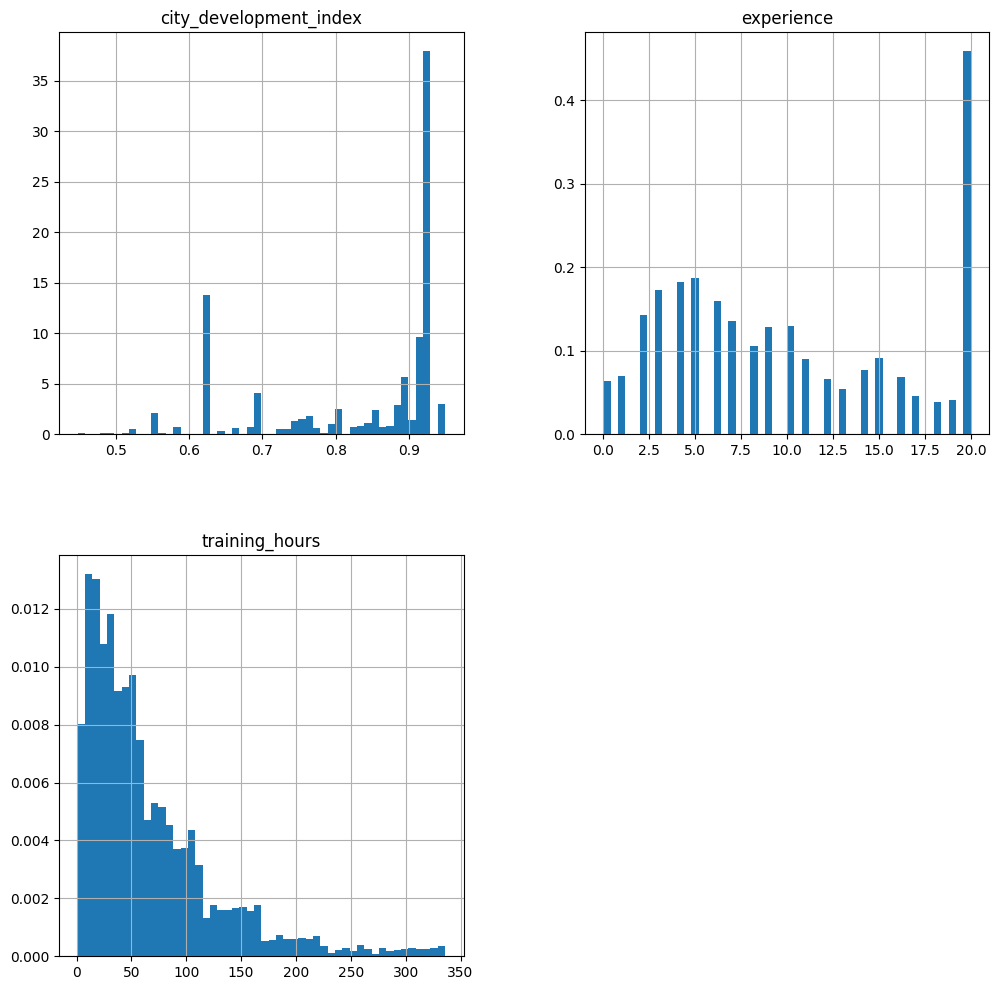

In [20]:
dff.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

<Axes: >

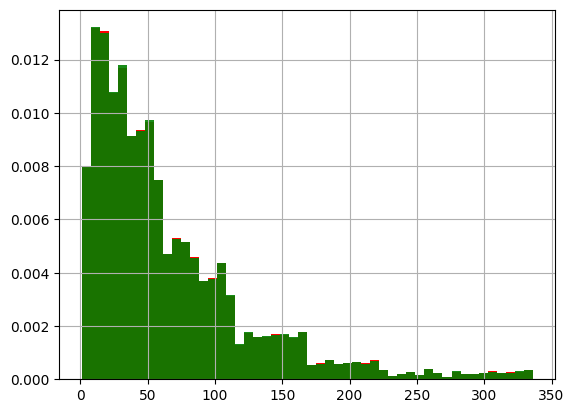

In [24]:
# check indivisually

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True,  color='red')

# after
dff['training_hours'].hist(bins=50, ax = ax, color='green', density=True, alpha=0.9)

<Axes: ylabel='Density'>

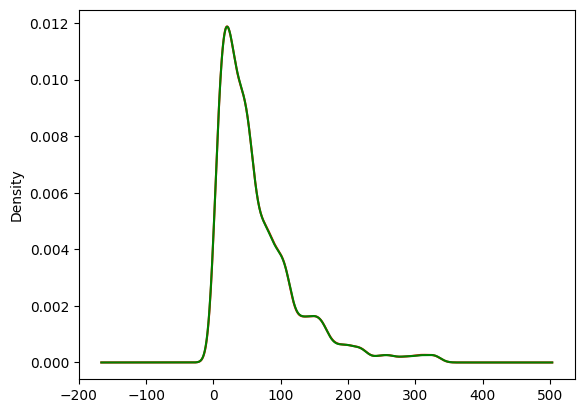

In [28]:
# check indivisually

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original data
df['training_hours'].plot.density(  color='red')

# after
dff['training_hours'].plot.density( color='green')

<Axes: >

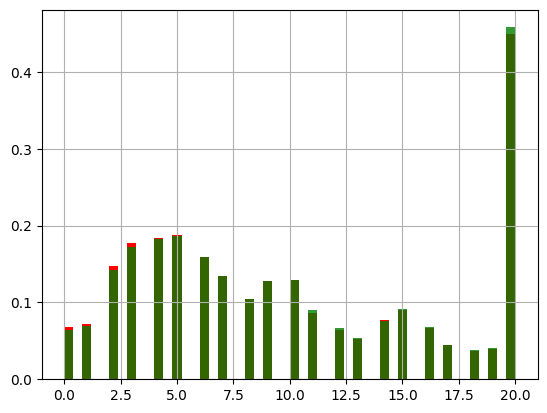

In [26]:
# check indivisually

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original data
df['experience'].hist(bins=50, ax=ax, density=True,  color='red')

# after
dff['experience'].hist(bins=50, ax = ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

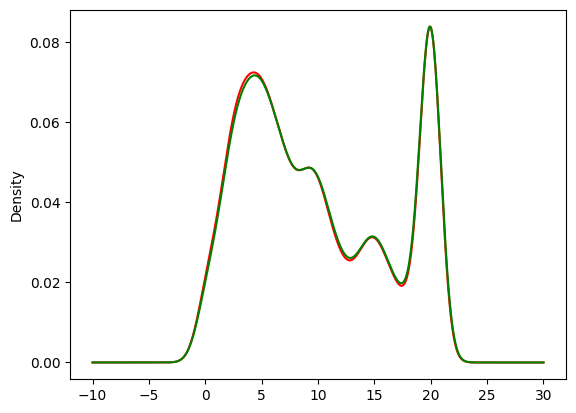

In [29]:
# check indivisually

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original data
df['experience'].plot.density(  color='red')

# after
dff['experience'].plot.density( color='green')

<Axes: >

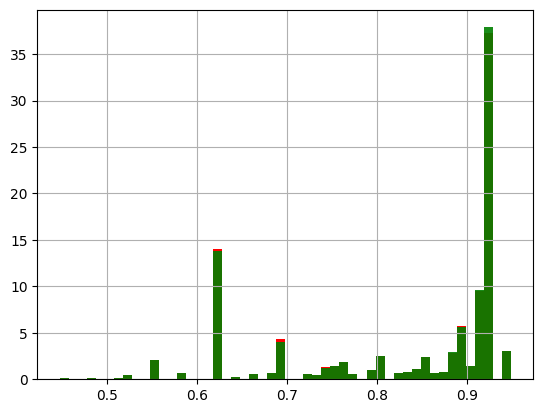

In [27]:
# check indivisually

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True,  color='red')

# after
dff['city_development_index'].hist(bins=50, ax = ax, color='green', density=True, alpha=0.9)

<Axes: ylabel='Density'>

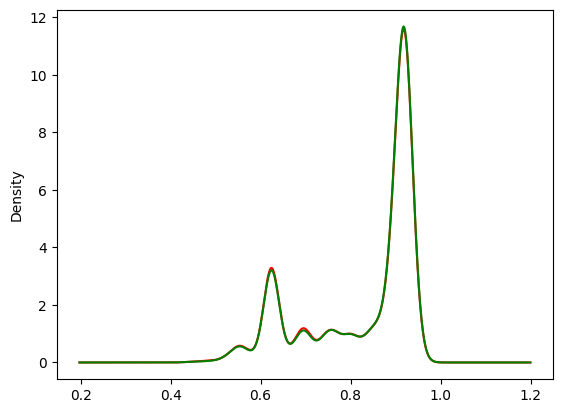

In [30]:
# check indivisually

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original data
df['city_development_index'].plot.density(  color='red')

# after
dff['city_development_index'].plot.density( color='green')

In [31]:
dff

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


In [34]:
# ratio

temp = pd.concat([
    # percenatage of rows as per category, original data
    df['enrolled_university'].value_counts() / len(df),

    # cca
    dff['enrolled_university'].value_counts() / len(dff)
], axis=1)

temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [35]:
# ratio

temp = pd.concat([
    # percenatage of rows as per category, original data
    df['education_level'].value_counts() / len(df),

    # cca
    dff['education_level'].value_counts() / len(dff)
], axis=1)

temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
